# Hex-Demand: Predicting Grocery Demand Using H3 Spatial Indexing

## Business Context
Last-minute grocery delivery platforms such as Zepto rely on accurate demand forecasting to ensure fast deliveries. To optimize operations, cities are divided into hexagonal grids using the H3 indexing system. Hexagons provide equal distances between neighboring cells, making them ideal for defining the service range of dark stores.

## Objective
The goal of this project is to:
1. Generate synthetic delivery location data (latitude and longitude).
2. Convert these locations into H3 hexagonal indices.
3. Aggregate demand within each hexagon.
4. Engineer a lag feature to capture temporal demand patterns.
5. Train a machine learning model to predict demand density.
6. Visualize predicted high-demand areas using an interactive Folium map.

## Tools and Libraries
- Pandas and NumPy for data manipulation.
- H3-py for spatial indexing.
- Scikit-learn for machine learning.
- Folium for interactive map visualization.
- Matplotlib and Seaborn for exploratory data analysis.

## Statistical Perspective
Demand prediction is treated as a regression problem where the target variable is the number of orders in each hexagon per hour. The model aims to minimize the Mean Squared Error (MSE), which measures the average squared difference between actual and predicted demand.

## Importing Required Libraries
We begin by importing the necessary Python libraries for data generation, spatial indexing, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# H3 spatial indexing
import h3

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import folium
from folium.plugins import HeatMap

# Set random seed for reproducibility
np.random.seed(42)

## Creating a Synthetic Dataset

Since real delivery data is confidential, we simulate order locations within Kolkata. 
Each record represents a delivery with:
- Latitude and Longitude
- Timestamp of the order
- Order value

The coordinates are generated around the central location of Kolkata.

In [2]:
# Central coordinates for Kolkata
center_lat, center_lon = 22.5726, 88.3639

# Number of synthetic orders
n_orders = 5000

# Generate random coordinates around the city
latitudes = center_lat + np.random.normal(0, 0.02, n_orders)
longitudes = center_lon + np.random.normal(0, 0.02, n_orders)

# Generate timestamps over a 24-hour period
start_time = datetime(2025, 1, 1)
timestamps = [start_time + timedelta(minutes=np.random.randint(0, 1440)) for _ in range(n_orders)]

# Generate synthetic order values
order_values = np.random.gamma(shape=2, scale=200, size=n_orders)

# Create DataFrame
df = pd.DataFrame({
    'latitude': latitudes,
    'longitude': longitudes,
    'timestamp': timestamps,
    'order_value': order_values
})

df.head()

,latitude,longitude,timestamp,order_value
0,22.582534,88.355425,2025-01-01 17:34:00,141.640511
1,22.569835,88.354832,2025-01-01 11:32:00,369.518850
2,22.585554,88.327987,2025-01-01 02:07:00,335.293448
3,22.603061,88.357298,2025-01-01 12:46:00,1014.948719
4,22.567917,88.378557,2025-01-01 21:57:00,387.493304


## Data Cleaning and Preprocessing

Data cleaning ensures reliability of analysis. We check for:
- Missing values
- Duplicate records
- Correct data types

We also extract the hour from the timestamp to capture temporal demand patterns.

In [3]:
# Check for missing values
print(df.isnull().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)

# Convert timestamp to datetime and extract hour
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

df.info()

latitude       0
longitude      0
timestamp      0
order_value    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   latitude     5000 non-null   float64       
 1   longitude    5000 non-null   float64       
 2   timestamp    5000 non-null   datetime64[us]
 3   order_value  5000 non-null   float64       
 4   hour         5000 non-null   int32         
dtypes: datetime64[us](1), float64(3), int32(1)
memory usage: 175.9 KB


## Converting Locations to H3 Hexagons

The H3 indexing system converts geographic coordinates into hexagonal grid cells. 
Resolution 8 or 9 is suitable for city-level analysis. In this project, we use resolution 8.

Mathematically, spatial aggregation reduces noise by grouping nearby points, enabling better estimation of demand density.

In [4]:
import h3

# Define H3 resolution
resolution = 8

# Convert latitude and longitude to H3 indices
df['h3_index'] = df.apply(
    lambda row: h3.latlng_to_cell(row['latitude'], row['longitude'], resolution),
    axis=1
)

df.head()

,latitude,longitude,timestamp,order_value,hour,h3_index
0,22.582534,88.355425,2025-01-01 17:34:00,141.640511,17,883cf2c641fffff
1,22.569835,88.354832,2025-01-01 11:32:00,369.518850,11,883cf2c66bfffff
2,22.585554,88.327987,2025-01-01 02:07:00,335.293448,2,883cf2d599fffff
3,22.603061,88.357298,2025-01-01 12:46:00,1014.948719,12,883cf2d4bdfffff
4,22.567917,88.378557,2025-01-01 21:57:00,387.493304,21,883cf2c601fffff


## Aggregating Demand per Hexagon

Demand density is defined as the number of orders within each hexagon for every hour. 
This aggregation transforms individual delivery events into meaningful spatial-temporal units.

In [5]:
# Aggregate demand per hexagon per hour
hex_demand = (
    df.groupby(['h3_index', 'hour'])
    .size()
    .reset_index(name='demand')
)

hex_demand.head()

,h3_index,hour,demand
0,883cf28905fffff,2,1
1,883cf28905fffff,5,1
2,883cf28905fffff,13,1
3,883cf28907fffff,22,1
4,883cf2890dfffff,13,1


## Feature Engineering: Lag Feature

Customer demand often follows temporal patterns. To capture this dependency, we create a lag feature:
- Lag 1: Demand in the previous hour.

This introduces an autoregressive component, helping the model learn temporal continuity.

In [6]:
# Sort values to ensure proper lag calculation
hex_demand.sort_values(by=['h3_index', 'hour'], inplace=True)

# Create lag feature
hex_demand['lag_1'] = hex_demand.groupby('h3_index')['demand'].shift(1)

# Remove rows with missing lag values
hex_demand.dropna(inplace=True)

hex_demand.head()

,h3_index,hour,demand,lag_1
1,883cf28905fffff,5,1,1.0
2,883cf28905fffff,13,1,1.0
5,883cf2890dfffff,17,1,1.0
7,883cf28921fffff,5,1,1.0
8,883cf28921fffff,7,1,1.0


## Exploratory Data Analysis

EDA helps in understanding demand patterns and relationships between variables.
We visualize:
1. Distribution of demand.
2. Relationship between lag demand and current demand.

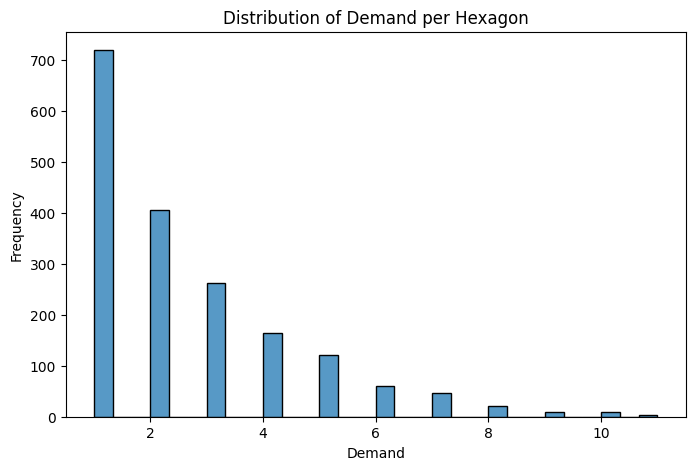

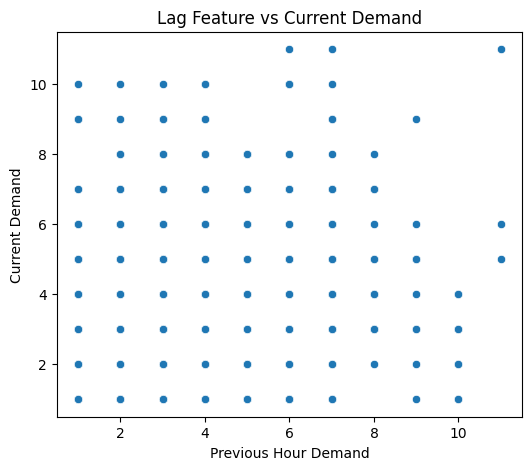

In [7]:
# Distribution of demand
plt.figure(figsize=(8, 5))
sns.histplot(hex_demand['demand'], bins=30)
plt.title('Distribution of Demand per Hexagon')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

# Relationship between lag and current demand
plt.figure(figsize=(6, 5))
sns.scatterplot(x='lag_1', y='demand', data=hex_demand)
plt.title('Lag Feature vs Current Demand')
plt.xlabel('Previous Hour Demand')
plt.ylabel('Current Demand')
plt.show()

## Preparing Data for Machine Learning

We select relevant features and split the dataset into training and testing sets. 
An 80-20 split ensures that the model is evaluated on unseen data.

In [8]:
# Feature matrix and target variable
X = hex_demand[['lag_1', 'hour']]
y = hex_demand['demand']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Selection and Training

We use the Random Forest Regressor because:
1. It captures non-linear relationships.
2. It is robust to outliers.
3. It reduces overfitting through ensemble averaging.

### Mathematical Insight
Random Forest predicts the output as the average of predictions from multiple decision trees:

Prediction = (1/N) × Σ(Tree Predictions)

The model minimizes Mean Squared Error (MSE):

MSE = (1/n) × Σ(y_actual − y_predicted)²

In [9]:
# Initialize and train the model
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## Model Evaluation

To evaluate model performance, we use:
- Mean Absolute Error (MAE): Average magnitude of errors.
- Root Mean Squared Error (RMSE): Penalizes larger errors.
- R-squared (R²): Proportion of variance explained by the model.

In [10]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 1.32
Root Mean Squared Error (RMSE): 1.79
R-squared (R2 Score): 0.01


## Predicting Demand for Visualization

We generate predictions for each hexagon to visualize areas with high expected demand.

In [11]:
# Add predictions to dataset
hex_demand['predicted_demand'] = model.predict(X)

## Converting H3 Indices to Geographic Coordinates

To visualize hexagons on a map, we convert H3 indices back to their geographic boundaries.

In [12]:
# Function to convert H3 index to polygon coordinates for Folium visualization
def h3_to_polygon(h3_index):
    
    boundary = h3.cell_to_boundary(h3_index)
    
    # Folium expects coordinates in (latitude, longitude) format
    return [(lat, lon) for lat, lon in boundary]


hex_demand['polygon'] = hex_demand['h3_index'].apply(h3_to_polygon)

## Interactive Map Visualization Using Folium

An interactive map allows stakeholders to easily identify high-demand regions. 
Hexagons are colored based on predicted demand intensity.

In [13]:
# Create base map centered around Kolkata
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Normalize predicted demand for color scaling
max_demand = hex_demand['predicted_demand'].max()

for _, row in hex_demand.iterrows():
    folium.Polygon(
        locations=row['polygon'],
        color=None,
        fill=True,
        fill_color='red',
        fill_opacity=row['predicted_demand'] / max_demand,
        popup=f"Predicted Demand: {row['predicted_demand']:.2f}"
    ).add_to(m)

# Save the map
m.save('hex_demand_map.html')

m

## Saving the Processed Dataset

Saving the processed dataset ensures reproducibility and allows further analysis.

In [14]:
hex_demand.to_csv('hex_demand_processed.csv', index=False)

## Business Insights and Conclusion

### Key Insights
1. Spatial aggregation using H3 indexing effectively identifies demand clusters.
2. The lag feature captures temporal continuity in customer behavior.
3. Random Forest provides accurate and stable predictions for demand density.
4. Interactive visualization enables business teams to make quick operational decisions.
5. The model can assist in optimizing dark store placement and inventory planning.

### Future Enhancements
- Incorporating weather and festival data.
- Using advanced models such as XGBoost or LSTM.
- Real-time demand prediction using streaming data.

### Final Thought
This project demonstrates how spatial analytics and machine learning can transform raw delivery data into actionable business intelligence, making it highly relevant for quick-commerce platforms.